## Importando bibliotecas 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Latex
import numpy as np

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/german_credit_data.csv", index_col = 0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


#### Leitura inicial

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


- Há valores ausentes nas colunas "Saving accounts" e "Checking accounts".

- Embora tipada como inteiro, a coluna Job representa uma variável categórica ordinal (níveis de 0 a 3).

In [6]:
# Mapeamento 
job_map = {
    '0': 'Não qualificado / Não residente',
    '1': 'Não qualificado / Residente',
    '2': 'Qualificado',
    '3': 'Altamente qualificado / Gestão'
}

df['Job'] = df['Job'].astype(str).map(job_map)

In [7]:
missing_table = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Percentual (%)', ascending=False)

missing_table

,Valores Ausentes,Percentual (%)
Checking account,394,39.4
Saving accounts,183,18.3
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0
Risk,0,0.0


In [8]:
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


#### Dicionário de Variáveis Categóricas

* **Sexo (Sex):** Masculino (male), Feminino (female)
* **Moradia (Housing):** Casa Própria (own), Casa Cedida (free), Casa Alugada (rent)
* **Qualificação Profissional (Job):**
  * 0: Não qualificado / Não residente
  * 1: Não qualificado / Residente
  * 2: Qualificado
  * 3: Altamente qualificado / Gestão
* **Conta Poupança (`Saving accounts`):** Saldo Baixo (`little`), Saldo Médio (`moderate`), Saldo Alto (`rich`), Saldo Muito Alto (`quite rich`), Não Informado / Sem Conta (`NaN`)
* **Conta Corrente (`Checking account`):** Saldo Baixo (`little`), Saldo Médio (`moderate`), Saldo Alto (`rich`), Não Informado / Sem Conta (`NaN`)
* **Motivo (`Purpose`):** Rádio/TV (`radio/TV`), Educação (`education`), Móveis/Equipamentos (`furniture/equipment`), Carro (`car`), Negócios (`business`), Eletrodomésticos (`domestic appliances`), Reparos (`repairs`), Férias/Outro (`vacation/others`)
* **Risco - Variável Alvo (`Risk`):** Bom Pagador (`good`), Mau Pagador (`bad`)

---

> **A partir disso, concluimos:**
> * **Variáveis Categóricas Ordinais:** `Job`, `Saving accounts` e `Checking account` 
> * **Variáveis Categóricas Nominais:** `Sex`, `Housing` e `Purpose` 
> * **Variável Alvo:** `Risk` (binária).
```[cite: 1]

# EDA [ Análise exploratória dos dados ]

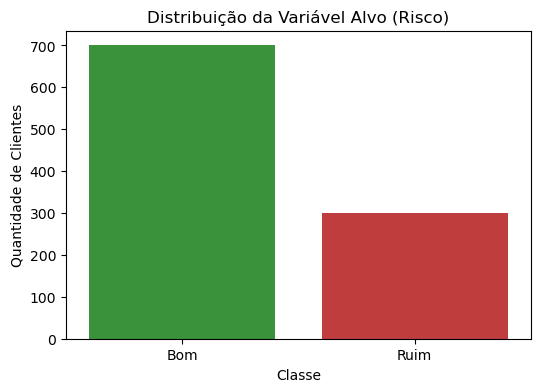

In [9]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Risk",
    order=["good", "bad"],
    palette={"good": "#2ca02c", "bad": "#d62728"},
    hue="Risk",
    legend=False,
)

plt.title("Distribuição da Variável Alvo (Risco)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Clientes")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Bom", "Ruim"])

plt.show()

70% dos clientes são classificados como good e 30% como bad (sendo bad a nossa classe de interesse)

#### Análise das variáveis numéricas

In [10]:
numeric_cols = ["Age", "Credit amount", "Duration"]

stats_summary = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
stats_summary['median'] = df[numeric_cols].median()
stats_summary['skewness'] = df[numeric_cols].skew()
stats_summary['kurtosis'] = df[numeric_cols].kurtosis()

stats_summary = stats_summary[[
    'count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness', 'kurtosis'
]].round(2)

stats_summary

,count,mean,std,min,25%,median,75%,max,skewness,kurtosis
Age,1000.0,35.55,11.38,19.0,27.0,33.0,42.00,75.0,1.02,0.60
Credit amount,1000.0,3271.26,2822.74,250.0,1365.5,2319.5,3972.25,18424.0,1.95,4.29
Duration,1000.0,20.90,12.06,4.0,12.0,18.0,24.00,72.0,1.09,0.92


As três variáveis apresentam assimetria positiva, evidenciada pelos valores de skewness superiores a 1 e pela média superior à mediana.

A maioria dos clientes contrata valores menores (mediana de 2.319,50 vs. média de 3.271,26), prazos curtos (mediana de 18 meses) e tem perfil jovem (mediana de 33 anos).

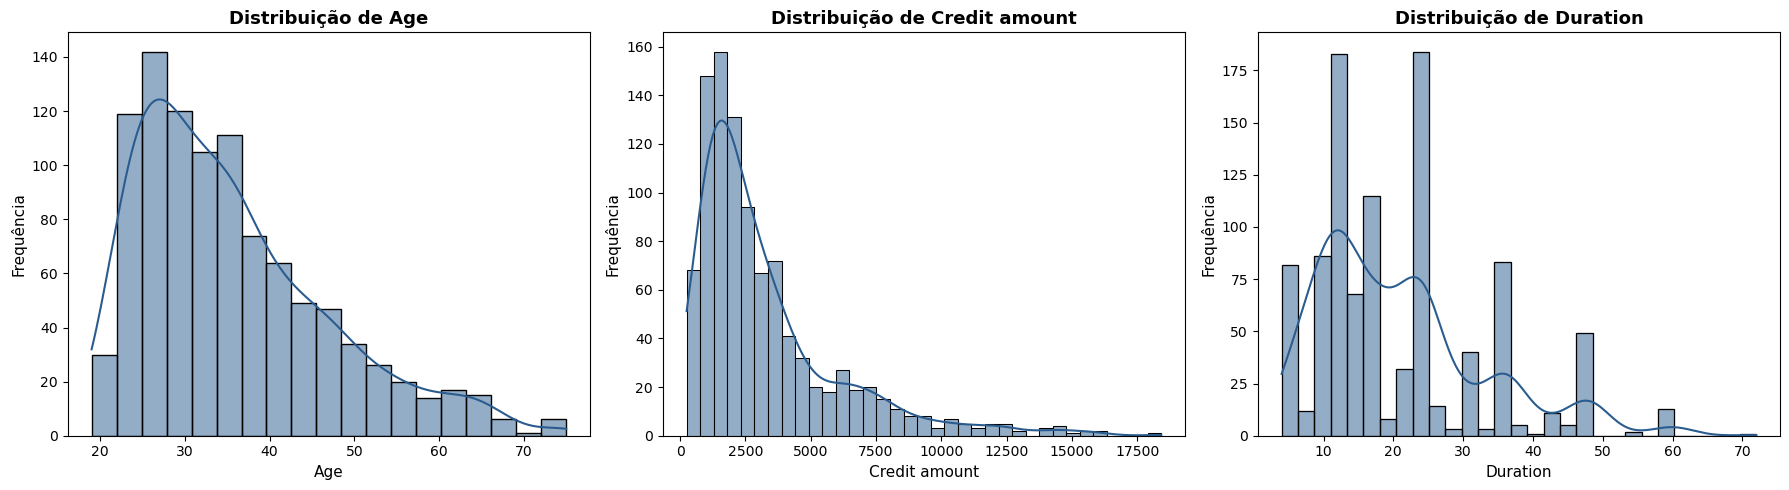

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color="#2b5c8f",
        ax=axes[i]
    )
    axes[i].set_title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequência', fontsize=11)

plt.tight_layout()
plt.show()

Confirma as suspeitas acima, com o cliente padrão sendo jovens (25–35 anos), que buscam empréstimos de menor valor (< 5.000) e com prazos contratuais curtos/médios (12 a 24 meses)

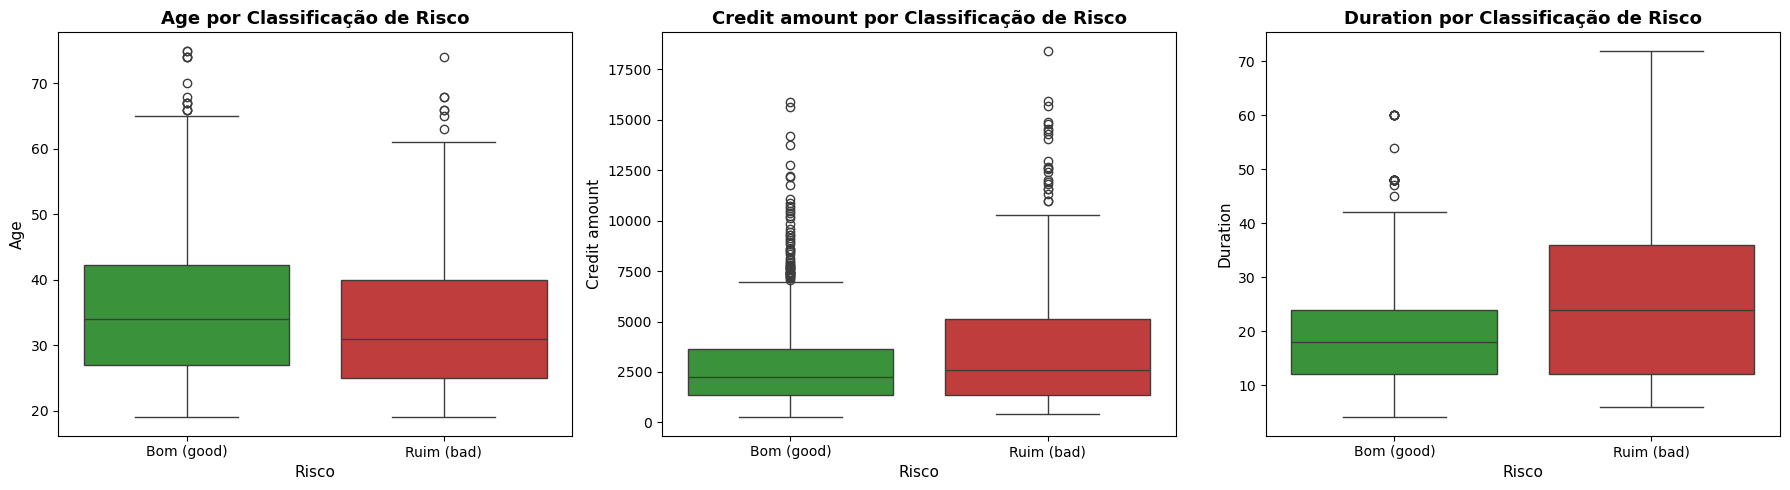

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x='Risk',
        y=col,
        hue='Risk',
        order=['good', 'bad'],
        palette={'good': '#2ca02c', 'bad': '#d62728'},
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} por Classificação de Risco', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Risco', fontsize=11)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Bom (good)', 'Ruim (bad)'])
    axes[i].set_ylabel(col, fontsize=11)

plt.tight_layout()
plt.show()

- Clientes inadimplentes concentram empréstimos de maior valor e prazos mais longos, agravando a severidade do prejuízo financeiro.

- A mediana da idade no grupo Ruim (bad) é ligeiramente menor (\~31 anos) do que no grupo Bom (good) (\~34 anos), relação a ser explorada

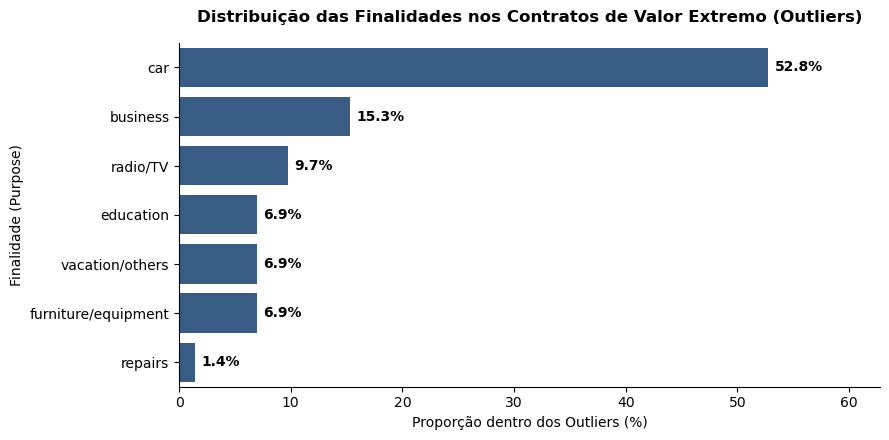

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
outlier_purpose = (
    df[df['is_outlier_amount']]['Purpose'].value_counts(normalize=True) * 100
).reset_index()
outlier_purpose.columns = ['Purpose', 'Percentage']

# Plot
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(
    data=outlier_purpose,
    y='Purpose',
    x='Percentage',
    color='#2b5c8f',
)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
    )

plt.title(
    'Distribuição das Finalidades nos Contratos de Valor Extremo (Outliers)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Proporção dentro dos Outliers (%)', fontsize=10)
plt.ylabel('Finalidade (Purpose)', fontsize=10)
plt.xlim(0, outlier_purpose['Percentage'].max() + 10)
sns.despine(right=True, top=True)

plt.tight_layout()
plt.show()

A análise de outliers identifica contratos com montantes mais elevados (ultrapassando 10.000 a 18.000), com forte concentração nas finalidades de veículos (car ~52,8%) e negócios (business ~15,3%), mas não podemos generalizar o comportamento dos outliers para explicar o restante dos dados

Os dados contendo os outliers devem ser mantidos na modelagem para captar essas relações

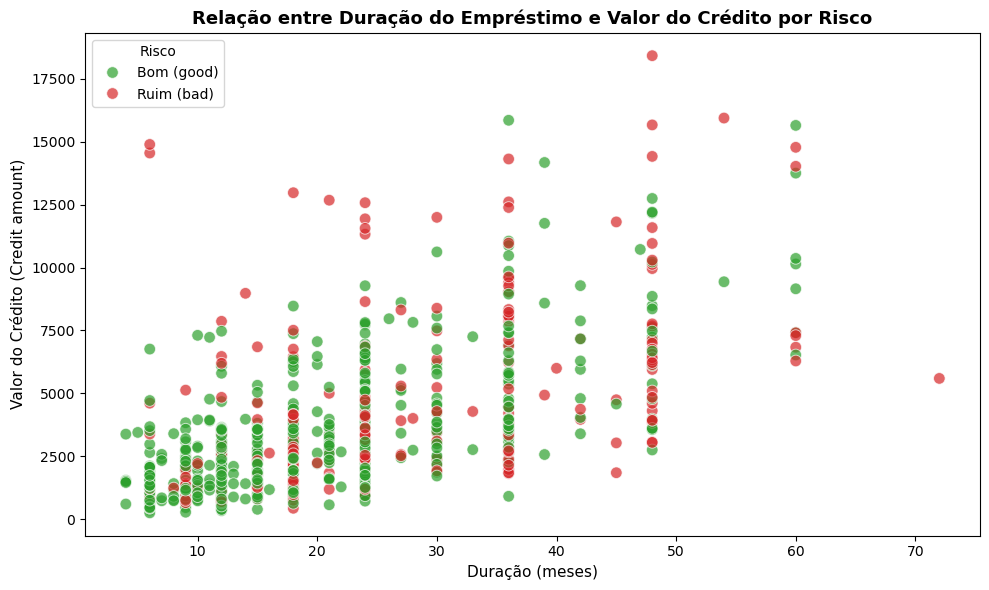

In [14]:
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x='Duration',
    y='Credit amount',
    hue='Risk',
    hue_order=['good', 'bad'],
    palette={'good': '#2ca02c', 'bad': '#d62728'},
    alpha=0.7,
    s=70
)

plt.title('Relação entre Duração do Empréstimo e Valor do Crédito por Risco', fontsize=13, fontweight='bold')
plt.xlabel('Duração (meses)', fontsize=11)
plt.ylabel('Valor do Crédito (Credit amount)', fontsize=11)

# Obtém os manipuladores originais com as cores corretas e renomeia apenas os textos
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Bom (good)', 'Ruim (bad)'], title='Risco', loc='upper left')

plt.tight_layout()
plt.show()

Observa-se uma associação positiva entre duração e valor do empréstimo, indicando que operações de maior valor tendem a apresentar prazos maiores.

#### Análise das variáveis categóricas

In [15]:
# Estatísticas das variáveis categóricas
df.describe(include="object")

,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,1000,817,606,1000,1000
unique,2,4,3,4,3,8,2
top,male,Qualificado,own,little,little,car,good
freq,690,630,713,603,274,337,700


- Há predominância masculina
- muitos clientes possuem casa própria.
- Boa parte dos empréstimos foi destinada à compra de veículos.

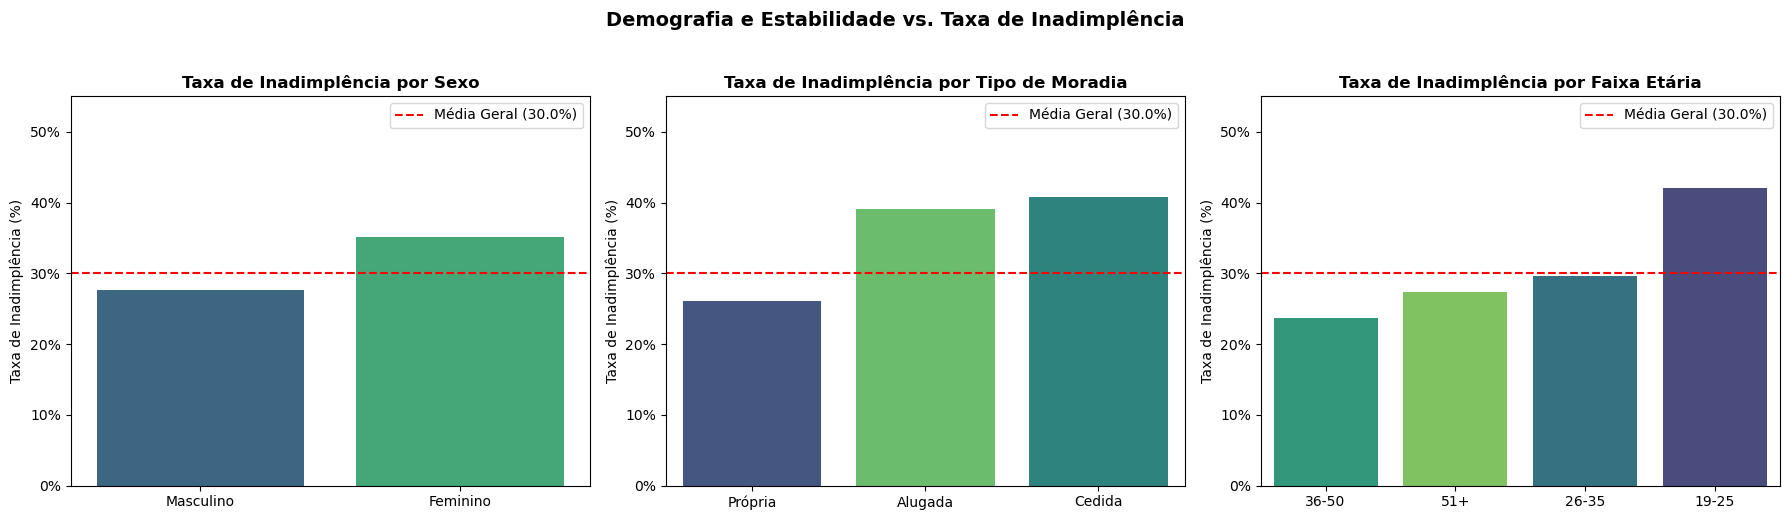

In [62]:
from matplotlib.ticker import PercentFormatter

df['Risco_Num'] = df['Risk'].map({'bad': 1, 'good': 0})

# faixas de idade para análise demográfica
df['Faixa_Idade'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 50, 75],
    labels=['19-25', '26-35', '36-50', '51+']
)

# Média geral de inadimplência da base (30%)
media_geral = df['Risco_Num'].mean()

#Demografia & Estabilidade 
grid1_config = [
    {
        'col': 'Sex',
        'title': 'Sexo',
        'labels': {'female': 'Feminino', 'male': 'Masculino'},
        'rot': 0
    },
    {
        'col': 'Housing',
        'title': 'Tipo de Moradia',
        'labels': {'own': 'Própria', 'rent': 'Alugada', 'free': 'Cedida'},
        'rot': 0
    },
    {
        'col': 'Faixa_Idade',
        'title': 'Faixa Etária',
        'labels': None,
        'rot': 0
    }
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, conf in enumerate(grid1_config):
    col = conf['col']
    ax = axes[i]
    
    order = df.groupby(col, observed=False)['Risco_Num'].mean().sort_values().index.tolist()
    
    sns.barplot(
        data=df,
        x=col,
        y='Risco_Num',
        hue=col,
        order=order,
        palette='viridis',
        errorbar=None,
        legend=False,
        ax=ax
    )
    
    ax.axhline(media_geral, color='red', linestyle='--', linewidth=1.5, label=f'Média Geral ({media_geral:.1%})')
    
    ax.set_title(f'Taxa de Inadimplência por {conf["title"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 0.55)
    ax.legend(loc='upper right')
    
    ax.set_xticks(range(len(order)))
    if conf['labels']:
        ax.set_xticklabels([conf['labels'].get(v, str(v)) for v in order], rotation=conf['rot'])
    else:
        ax.set_xticklabels(order, rotation=conf['rot'])

plt.suptitle('Demografia e Estabilidade vs. Taxa de Inadimplência', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()



Sexo: Na amostra, mulheres apresentam taxa de inadimplência de aproximadamente 35%, contra 28% entre homens. Essa diferença indica uma associação entre gênero e risco na amostra, mas não permite inferir causalidade

Tipo de Moradia: Clientes com moradia própria apresentam menor taxa de inadimplência na amostra, indicando uma possível associação entre tipo de moradia e risco de crédito.

Faixa Etária: A faixa de 19–25 anos apresenta a maior taxa de inadimplência (\~42%), enquanto a faixa de 36–50 anos apresenta a menor (\~24%). Observa-se, portanto, uma associação entre faixa etária e taxa de inadimplência na amostra

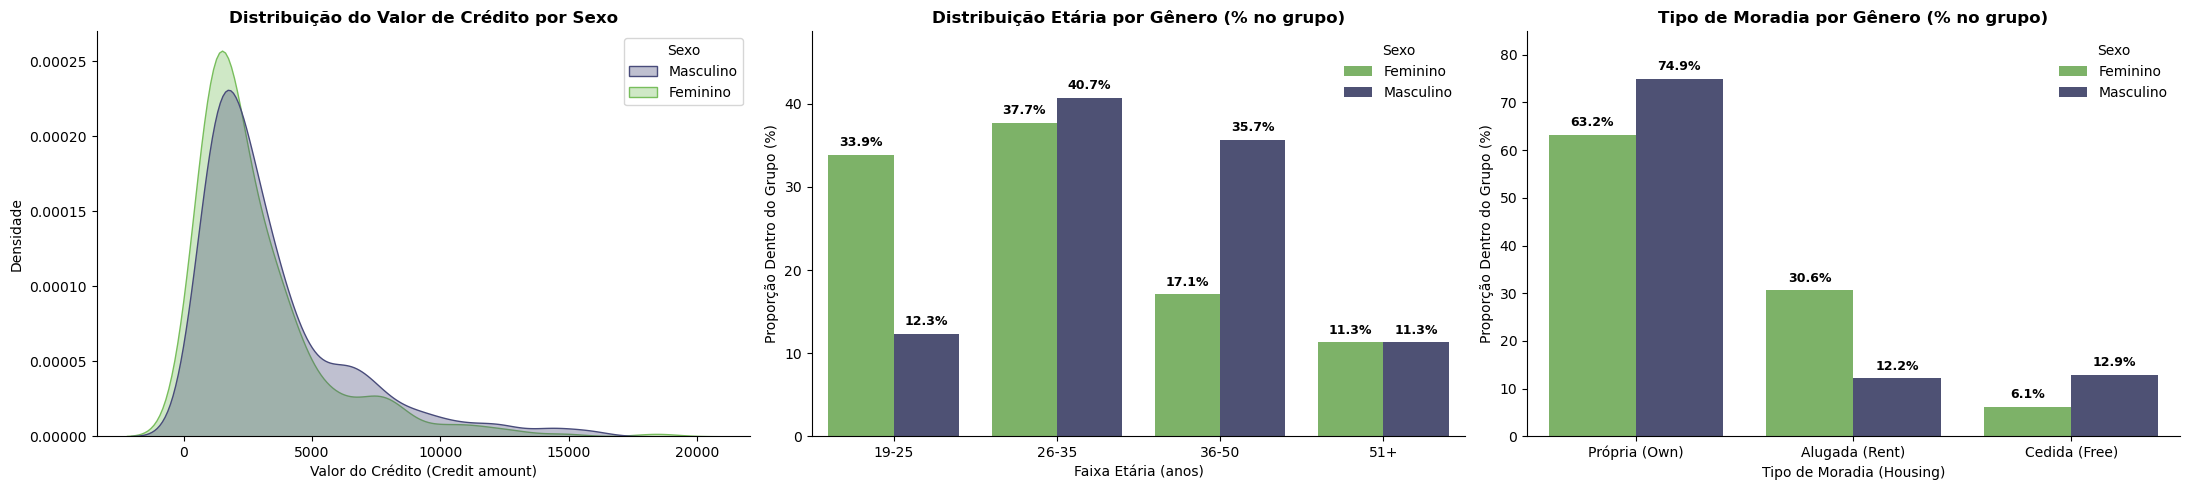

In [38]:
if 'Age_Group' not in df.columns:
  df['Age_Group'] = pd.cut(
      df['Age'],
      bins=[18, 25, 35, 50, 100],
      labels=['19-25', '26-35', '36-50', '51+'],
  )

df_plot = df.copy()
df_plot['Sexo'] = df_plot['Sex'].map({'female': 'Feminino', 'male': 'Masculino'})
df_plot['Moradia'] = df_plot['Housing'].map(
    {'own': 'Própria (Own)', 'rent': 'Alugada (Rent)', 'free': 'Cedida (Free)'}
)

#Proporção de Faixa Etária por Gênero
age_gender = (
    pd.crosstab(df_plot['Age_Group'], df_plot['Sexo'], normalize='columns') * 100
).reset_index()

age_gender_melted = pd.melt(
    age_gender,
    id_vars=['Age_Group'],
    value_vars=['Feminino', 'Masculino'],
    var_name='Sexo',
    value_name='Proporcao',
)

#Proporção de Tipo de Moradia por Gênero
housing_gender = (
    pd.crosstab(df_plot['Moradia'], df_plot['Sexo'], normalize='columns') * 100
).reset_index()

housing_gender_melted = pd.melt(
    housing_gender,
    id_vars=['Moradia'],
    value_vars=['Feminino', 'Masculino'],
    var_name='Sexo',
    value_name='Proporcao',
)
cores = {'Feminino': '#78be5c', 'Masculino': '#484b7a'}

# 3. Criação da figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

#Densidade do Valor de Crédito (KDE)
sns.kdeplot(
    data=df_plot,
    x='Credit amount',
    hue='Sexo',
    common_norm=False,
    palette=cores,
    fill=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title(
    'Distribuição do Valor de Crédito por Sexo', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Valor do Crédito (Credit amount)', fontsize=10)
axes[0].set_ylabel('Densidade', fontsize=10)
sns.despine(ax=axes[0], top=True, right=True)

#Distribuição Etária Proporcional (Barras)
ax_bar_age = sns.barplot(
    data=age_gender_melted,
    x='Age_Group',
    y='Proporcao',
    hue='Sexo',
    palette=cores,
    ax=axes[1],
)

for p in ax_bar_age.patches:
  height = p.get_height()
  if height > 0:
    ax_bar_age.annotate(
        f'{height:.1f}%',
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
    )

axes[1].set_title(
    'Distribuição Etária por Gênero (% no grupo)',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_xlabel('Faixa Etária (anos)', fontsize=10)
axes[1].set_ylabel('Proporção Dentro do Grupo (%)', fontsize=10)
axes[1].set_ylim(0, age_gender_melted['Proporcao'].max() + 8)
axes[1].legend(title='Sexo', frameon=True, facecolor='white', edgecolor='none')
sns.despine(ax=axes[1], top=True, right=True)

# Distribuição de Moradia Proporcional (Barras)
ax_bar_house = sns.barplot(
    data=housing_gender_melted,
    x='Moradia',
    y='Proporcao',
    hue='Sexo',
    palette=cores,
    order=['Própria (Own)', 'Alugada (Rent)', 'Cedida (Free)'],
    ax=axes[2],
)

for p in ax_bar_house.patches:
  height = p.get_height()
  if height > 0:
    ax_bar_house.annotate(
        f'{height:.1f}%',
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
    )

axes[2].set_title(
    'Tipo de Moradia por Gênero (% no grupo)', fontsize=12, fontweight='bold'
)
axes[2].set_xlabel('Tipo de Moradia (Housing)', fontsize=10)
axes[2].set_ylabel('Proporção Dentro do Grupo (%)', fontsize=10)
axes[2].set_ylim(0, housing_gender_melted['Proporcao'].max() + 10)
axes[2].legend(title='Sexo', frameon=True, facecolor='white', edgecolor='none')
sns.despine(ax=axes[2], top=True, right=True)

plt.tight_layout()
plt.show()

O gênero, isoladamente, não deve ser interpretado como fator causal da inadimplência. A maior taxa observada no grupo feminino pode estar associada ao perfil da amostra, que apresenta maior proporção de indivíduos mais jovens e com menor posse de moradia própria.

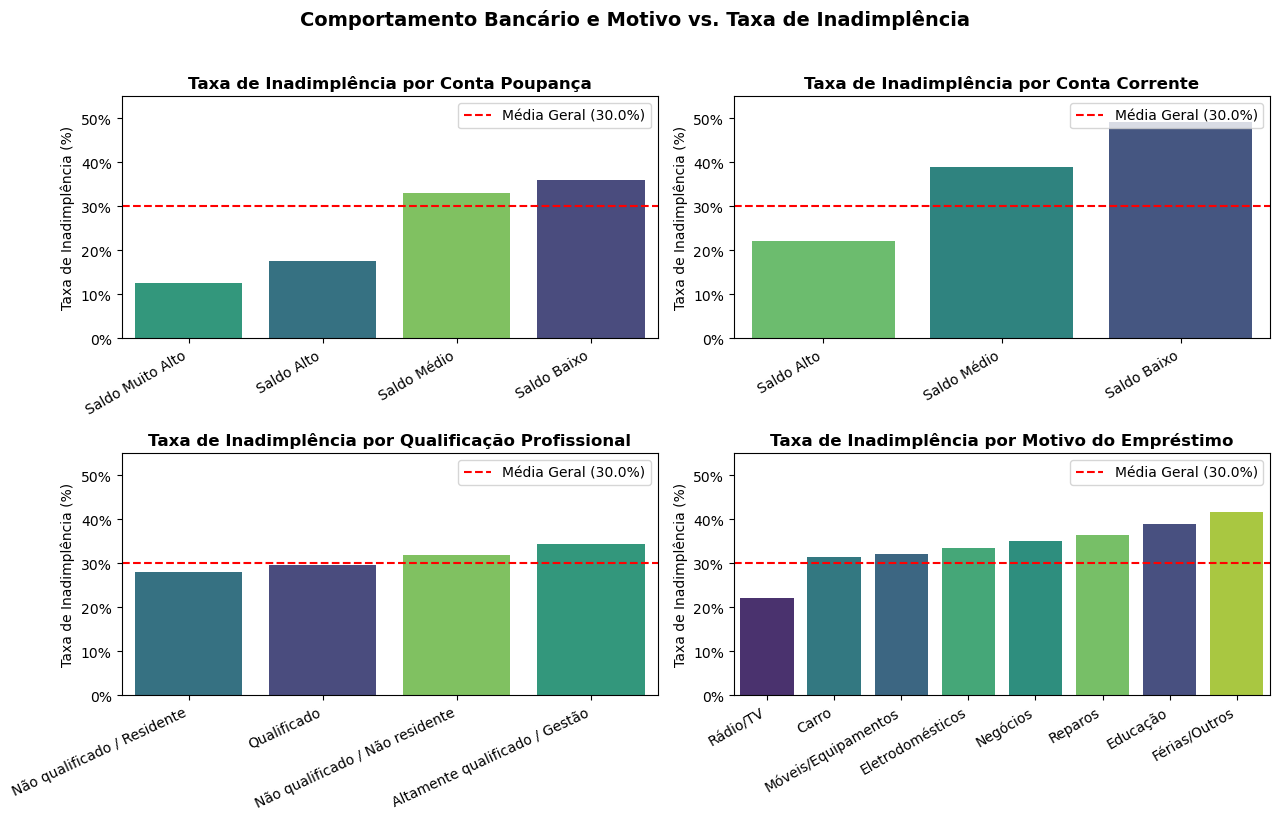

In [42]:
#Comportamento Bancário & Motivo (Saving, Checking, Job, Purpose)
grid2_config = [
    {
        'col': 'Saving accounts',
        'title': 'Conta Poupança',
        'labels': {'little': 'Saldo Baixo', 'moderate': 'Saldo Médio', 'quite rich': 'Saldo Alto', 'rich': 'Saldo Muito Alto'},
        'rot': 30
    },
    {
        'col': 'Checking account',
        'title': 'Conta Corrente',
        'labels': {'little': 'Saldo Baixo', 'moderate': 'Saldo Médio', 'rich': 'Saldo Alto'},
        'rot': 30
    },
    {
        'col': 'Job',
        'title': 'Qualificação Profissional',
        'labels': None,
        'rot': 25
    },
    {
        'col': 'Purpose',
        'title': 'Motivo do Empréstimo',
        'labels': {
            'radio/TV': 'Rádio/TV',
            'education': 'Educação',
            'furniture/equipment': 'Móveis/Equipamentos',
            'car': 'Carro',
            'business': 'Negócios',
            'domestic appliances': 'Eletrodomésticos',
            'repairs': 'Reparos',
            'vacation/others': 'Férias/Outros'
        },
        'rot': 30
    }
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, conf in enumerate(grid2_config):
    col = conf['col']
    ax = axes[i]
    
    order = df.groupby(col, observed=False)['Risco_Num'].mean().sort_values().index.tolist()
    
    sns.barplot(
        data=df,
        x=col,
        y='Risco_Num',
        hue=col,
        order=order,
        palette='viridis',
        errorbar=None,
        legend=False,
        ax=ax
    )
    
    ax.axhline(media_geral, color='red', linestyle='--', linewidth=1.5, label=f'Média Geral ({media_geral:.1%})')
    
    ax.set_title(f'Taxa de Inadimplência por {conf["title"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 0.55)
    ax.legend(loc='upper right')
    
    ax.set_xticks(range(len(order)))
    if conf['labels']:
        ax.set_xticklabels([conf['labels'].get(v, str(v)) for v in order], rotation=conf['rot'], ha='right')
    else:
        ax.set_xticklabels(order, rotation=conf['rot'], ha='right')

plt.suptitle('Comportamento Bancário e Motivo vs. Taxa de Inadimplência', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



- **Conta Poupança:** Observa-se uma relação inversa entre o nível de poupança e a inadimplência, que cai de aproximadamente 36% no saldo baixo para 12% no saldo muito alto.

- **Conta Corrente:** Apresenta uma das maiores diferenças nas taxas de inadimplência entre as categorias, indicando forte associação com o risco observado na amostra.

- **Qualificação Profissional:** Apresenta menor poder discriminativo, com taxas de inadimplência variando relativamente pouco, entre aproximadamente 28% e 34%.

- **Motivo do Empréstimo:** As finalidades relacionadas a bens duráveis apresentam menor taxa de inadimplência (\~22%), enquanto Educação e Férias apresentam taxas mais elevadas (\~39% – 42%).

--- Ausência de Informação em Conta Corrente vs. Risco ---


Risk,Total_Clientes,Bom Pagador (%),Mau Pagador (%)
Status_Conta_Corrente,,,
Informação Ausente,394,88.32,11.68
Informação Preenchida,606,58.09,41.91


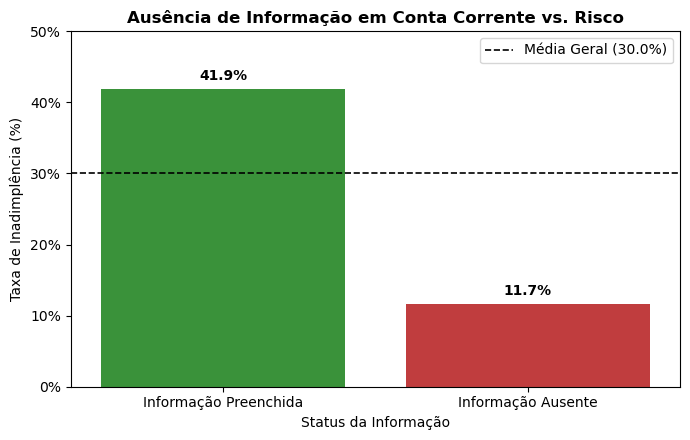

--- Ausência de Informação em Poupança vs. Risco ---


Risk,Total_Clientes,Bom Pagador (%),Mau Pagador (%)
Status_Poupanca,,,
Informação Ausente,183,82.51,17.49
Informação Preenchida,817,67.20,32.80


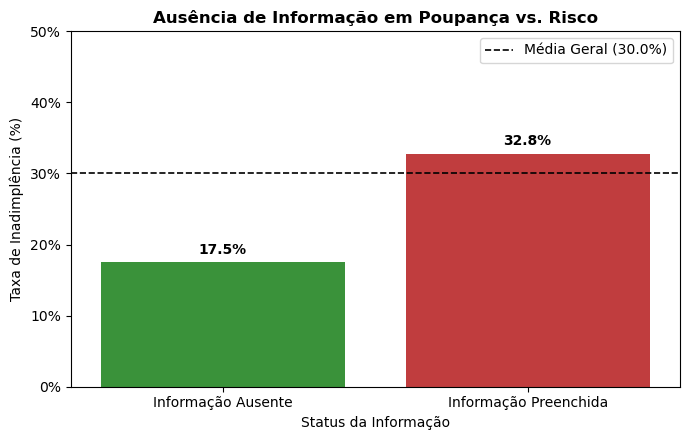

In [60]:
# Criar status de ausência/presença
df['Status_Conta_Corrente'] = df['Checking account'].apply(
    lambda x: 'Informação Ausente' if pd.isnull(x)
    else 'Informação Preenchida'
)

df['Status_Poupanca'] = df['Saving accounts'].apply(
    lambda x: 'Informação Ausente' if pd.isnull(x)
    else 'Informação Preenchida'
)

def analisar_nulos(coluna_status, titulo, xlabel):

    # Tabela cruzada
    crosstab = pd.crosstab(
        df[coluna_status],
        df['Risk'],
        normalize='index'
    ).mul(100).round(2)

    crosstab['Total_Clientes'] = (
        df[coluna_status].value_counts()
    )

    crosstab = crosstab.rename(
        columns={
            'good': 'Bom Pagador (%)',
            'bad': 'Mau Pagador (%)'
        }
    )

    print(f'--- {titulo} ---')

    display(
        crosstab[
            [
                'Total_Clientes',
                'Bom Pagador (%)',
                'Mau Pagador (%)'
            ]
        ]
    )
    # Gráfico
    plt.figure(figsize=(7, 4.5))

    ax = sns.barplot(
        data=df,
        x=coluna_status,
        y='Risco_Num',
        hue=coluna_status,
        palette=['#2ca02c', '#d62728'],
        errorbar=None,
        legend=False
    )

    # Média geral
    ax.axhline(
        media_geral,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=f'Média Geral ({media_geral:.1%})'
    )

    ax.set_title(
        titulo,
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel(
        'Taxa de Inadimplência (%)',
        fontsize=10
    )

    ax.set_xlabel(xlabel)

    ax.yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    ax.set_ylim(0, 0.50)

    ax.legend(loc='upper right')

    # Valores sobre as barras
    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{height:.1%}',
            xy=(
                p.get_x() + p.get_width() / 2,
                height
            ),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. CHECKING ACCOUNT
# ============================================================

analisar_nulos(
    coluna_status='Status_Conta_Corrente',
    titulo='Ausência de Informação em Conta Corrente vs. Risco',
    xlabel='Status da Informação'
)


# ============================================================
# 2. SAVING ACCOUNTS
# ============================================================

analisar_nulos(
    coluna_status='Status_Poupanca',
    titulo='Ausência de Informação em Poupança vs. Risco',
    xlabel='Status da Informação'
)

A ausência de informações apresenta diferenças nas taxas de inadimplência. Em `Checking account`, clientes com informação ausente apresentam 11,7% de inadimplência, contra 41,9% entre aqueles com a informação preenchida. Para `Saving accounts`, as taxas são de 17,5% e 32,8%, respectivamente. Esses resultados sugerem que o padrão de ausência pode conter informação relevante para a modelagem preditiva.

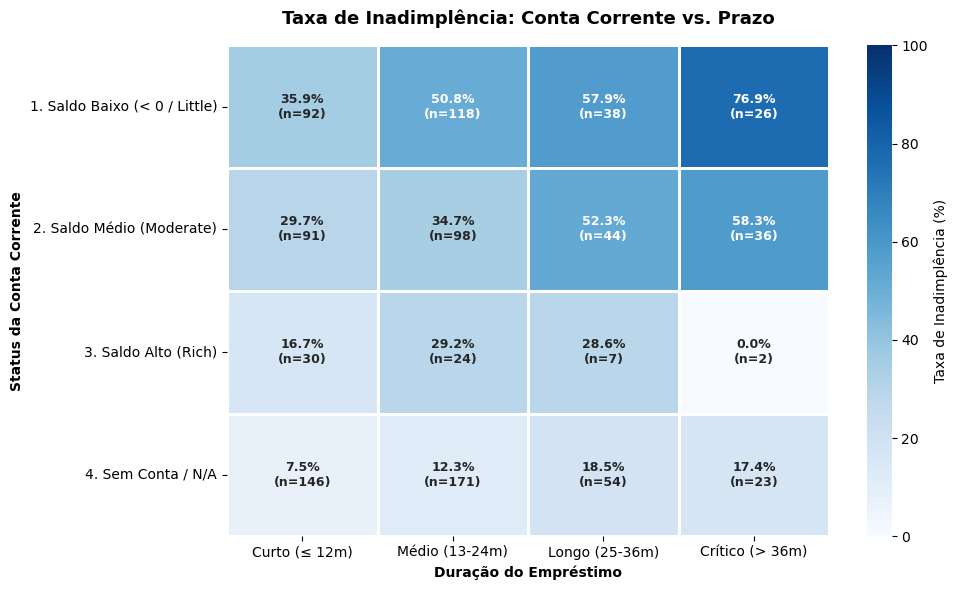

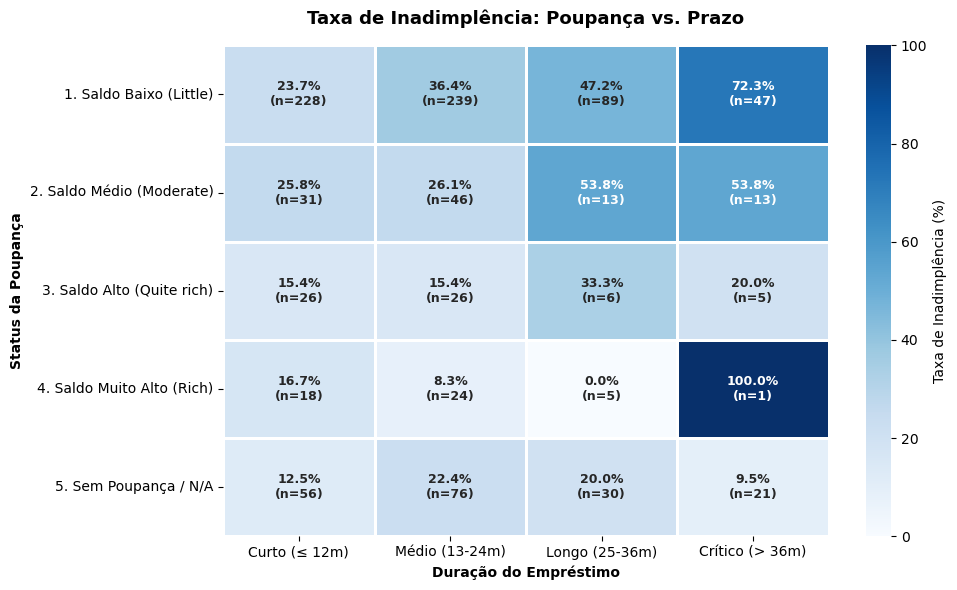

In [61]:
def analisar_interacao(df, categoria, titulo, eixo_y):

    # Taxa de inadimplência
    pivot_rate = df.pivot_table(
        index=categoria,
        columns='Duration_Group',
        values='Risk',
        aggfunc=lambda x: (x == 'bad').mean() * 100,
        observed=False
    )

    # Tamanho da amostra
    pivot_n = df.pivot_table(
        index=categoria,
        columns='Duration_Group',
        values='Risk',
        aggfunc='size',
        observed=False
    )

    # Anotações: taxa + n
    annot = pivot_rate.copy().astype(object)

    for row in pivot_rate.index:
        for col in pivot_rate.columns:

            rate = pivot_rate.loc[row, col]
            n = pivot_n.loc[row, col]

            if pd.notna(rate):
                annot.loc[row, col] = (
                    f'{rate:.1f}%\n(n={int(n)})'
                )
            else:
                annot.loc[row, col] = ''

    # Heatmap
    plt.figure(figsize=(10, 6))

    sns.heatmap(
        pivot_rate,
        annot=annot,
        fmt='',
        cmap='Blues',
        vmin=0,
        vmax=100,
        linewidths=0.8,
        linecolor='white',
        cbar_kws={
            'label': 'Taxa de Inadimplência (%)'
        },
        annot_kws={
            'size': 9,
            'weight': 'bold'
        }
    )

    plt.title(
        titulo,
        fontsize=13,
        fontweight='bold',
        pad=15
    )

    plt.xlabel(
        'Duração do Empréstimo',
        fontsize=10,
        fontweight='bold'
    )

    plt.ylabel(
        eixo_y,
        fontsize=10,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


# Conta corrente × duração
analisar_interacao(
    df_analysis,
    'Checking_Level',
    'Taxa de Inadimplência: Conta Corrente vs. Prazo',
    'Status da Conta Corrente'
)

# Poupança × duração
analisar_interacao(
    df_analysis,
    'Saving_Level',
    'Taxa de Inadimplência: Poupança vs. Prazo',
    'Status da Poupança'
)

Observa-se maior taxa de inadimplência em empréstimos de maior duração, principalmente entre clientes com menores saldos em conta e poupança. Algumas categorias possuem amostras reduzidas e devem ser interpretadas com cautela

#### Análise de correlação entre as variáveis

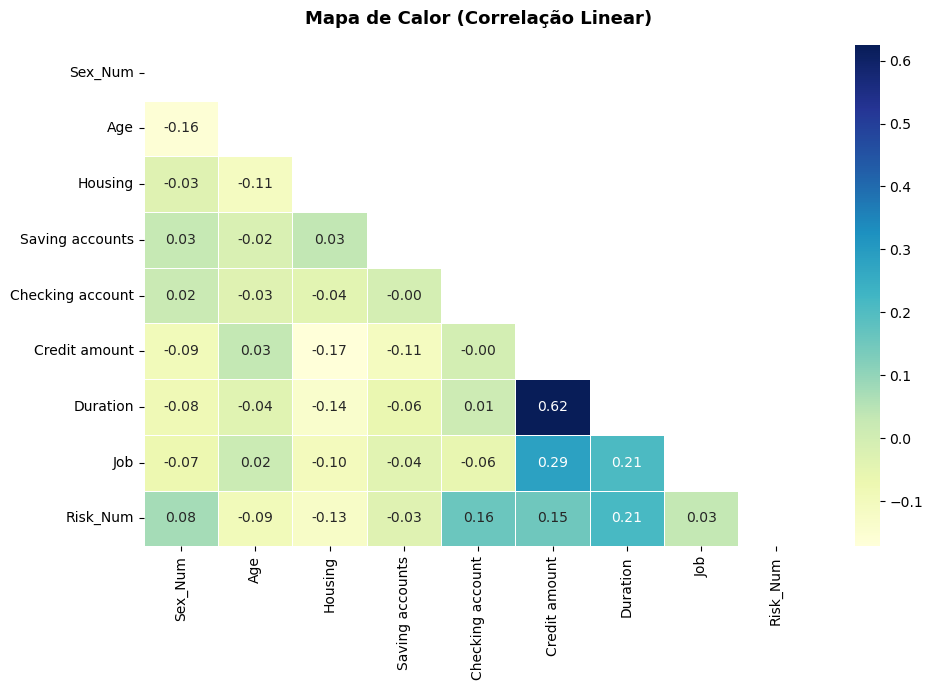

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_heatmap = df.copy()

def SC_LabelEncoder(x):
    val = str(x).lower()
    if "little" in val: return 1
    elif "moderate" in val: return 2
    elif "quite rich" in val: return 3
    elif "rich" in val: return 4
    else: return 0

def H_LabelEncoder(x):
    val = str(x).lower()
    if "free" in val: return 0
    elif "rent" in val: return 1
    elif "own" in val: return 2
    else: return 0


def Job_LabelEncoder(x):
    val = str(x)
    if val == 'Não qualificado / Não residente': return 0
    elif val == 'Não qualificado / Residente': return 1
    elif val == 'Qualificado': return 2
    elif val == 'Altamente qualificado / Gestão': return 3
    else:

        try: return int(val) 
        except: return 0

df_heatmap["Saving accounts"] = df_heatmap["Saving accounts"].apply(SC_LabelEncoder)
df_heatmap["Checking account"] = df_heatmap["Checking account"].apply(SC_LabelEncoder)
df_heatmap["Housing"] = df_heatmap["Housing"].apply(H_LabelEncoder)
df_heatmap["Job"] = df_heatmap["Job"].apply(Job_LabelEncoder) 

df_heatmap['Risk_Num'] = df_heatmap['Risk'].map({'good': 0, 'bad': 1})
df_heatmap['Sex_Num'] = df_heatmap['Sex'].map({'male': 0, 'female': 1})

cols = ['Sex_Num', 'Age', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Job', 'Risk_Num']
corr = df_heatmap[cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="YlGnBu", linewidths=.5, fmt=".2f")
plt.title("Mapa de Calor (Correlação Linear)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

- A principal correlação observada é entre Credit amount e Duration (r ≈ 0,62), indicando uma relação positiva moderada/forte: empréstimos de maior valor tendem a apresentar prazos maiores. As demais variáveis apresentam correlações fracas, indicando pouca relação linear entre si